In [ ]:
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pandas import read_csv
from torch import Tensor
from tqdm import trange

from datasets import CubeObstacle, CylinderObstacle
from utils.tools import calc_sig_strength_gpu
from utils.config import Hyperparameters as hp

random_seed = 42

In [1]:
# define the obstacles

# Create obstacles and convert to torch tensors

torch.manual_seed(random_seed)
np.random.seed(random_seed)
if hp.device == "cuda":
    torch.cuda.manual_seed_all(random_seed)

obstacle_ls = [
    CubeObstacle(-30, 25, 35, 60, 20, 0.1),
    CubeObstacle(-30, -25, 45, 10, 35, 0.1),
    CubeObstacle(-30, -60, 35, 60, 20, 0.1),
    CubeObstacle(50, -20, 35, 25, 25, 0.1),
    CylinderObstacle(10, -5,  70, 15, 0.1),
]

obst_points = []
for obstacle in obstacle_ls:
    obst_points.append(torch.tensor(obstacle.points, dtype=torch.float32))

obst_points = torch.cat([op for op in obst_points], dim=1).mT.to(hp.device)

NameError: name 'torch' is not defined

In [ ]:
def brute_force_blockage(gn_tensor: Tensor, height: float = 70, chunk_size: int = 1000, device: str = 'cpu'):
    x = torch.arange(-100, 100.01, 0.01, device=device)
    y = torch.arange(-100, 100.01, 0.01, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    Z = torch.full_like(X, height, device=device)
    grid = torch.stack([X, Y, Z], dim=-1)
    n, m, _ = grid.shape

    results = []

    for i in trange(0, n, chunk_size):
        grid_chunk = grid[i: i + chunk_size].reshape(-1, 3)
        result_se = calc_sig_strength_gpu(grid_chunk, gn_tensor, obst_points)
        results.append(result_se.cpu())

    result_se = torch.cat(results, dim=0)
    return result_se

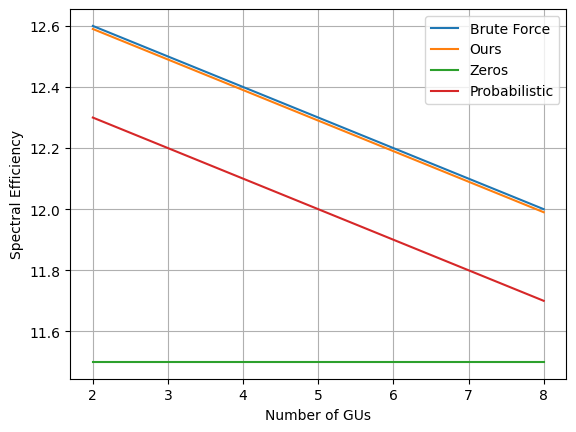

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x축 값을 2부터 8까지 생성 (길이 7)
x = np.arange(2, 9)

brute_force = np.array([12.6, 12.5, 12.4, 12.3, 12.2, 12.1, 12])
ours = np.array([12.59, 12.49, 12.39, 12.29, 12.19, 12.09, 11.99])
zeros = np.array([11.5, 11.5, 11.5, 11.5, 11.5, 11.5, 11.5])
prob = np.array([12.3, 12.2, 12.1, 12.0, 11.9, 11.8, 11.7])

plt.plot(x, brute_force, label='Brute Force')
plt.plot(x, ours, label='Ours')
plt.plot(x, zeros, label='Zeros')
plt.plot(x, prob, label='Probabilistic')

plt.xlabel('Number of GUs')
plt.ylabel('Spectral Efficiency')
plt.legend()
plt.grid()
plt.show()


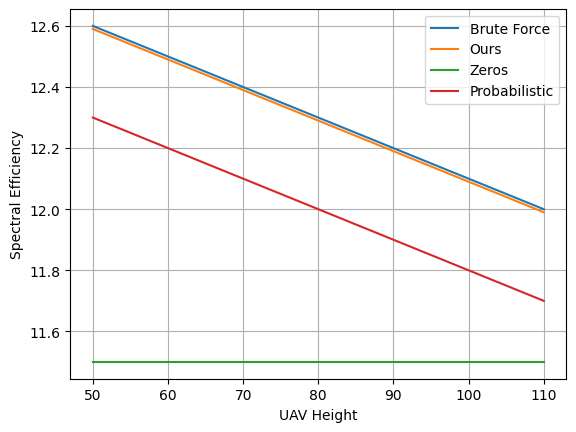

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x축 값을 2부터 8까지 생성 (길이 7)
x = np.arange(50, 120, 10)

brute_force = np.array([12.6, 12.5, 12.4, 12.3, 12.2, 12.1, 12])
ours = np.array([12.59, 12.49, 12.39, 12.29, 12.19, 12.09, 11.99])
zeros = np.array([11.5, 11.5, 11.5, 11.5, 11.5, 11.5, 11.5])
prob = np.array([12.3, 12.2, 12.1, 12.0, 11.9, 11.8, 11.7])

plt.plot(x, brute_force, label='Brute Force')
plt.plot(x, ours, label='Ours')
plt.plot(x, zeros, label='Zeros')
plt.plot(x, prob, label='Probabilistic')

plt.xlabel('UAV Height')
plt.ylabel('Spectral Efficiency')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('matlab/data/test.csv')
df.head()

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,43.005120,0.0,-57.3,36.1,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,-17.990965,0.0,-84.7,-60.9,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,39.862230,0.0,73.4,-67.8,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,-78.762474,0.0,-41.4,-66.4,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,-27.882648,0.0,55.6,-35.6,50


In [ ]:
df['prob_x'] = None
df['prob_y'] = None
df['prob_z'] = 50

df.loc[0, 'prob_x'] = 1
df.head()

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z,prob_x,prob_y,prob_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,43.005120,0.0,-57.3,36.1,50,1,None,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,-17.990965,0.0,-84.7,-60.9,50,None,None,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,39.862230,0.0,73.4,-67.8,50,None,None,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,-78.762474,0.0,-41.4,-66.4,50,None,None,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,-27.882648,0.0,55.6,-35.6,50,None,None,50


In [ ]:
import numpy as np
import torch
from utils.config import Hyperparameters as hp

gn_sets = df[['gnd1_x', 'gnd1_y', 'gnd1_z',
              'gnd2_x', 'gnd2_y', 'gnd2_z',
              'gnd3_x', 'gnd3_y', 'gnd3_z',
              'gnd4_x', 'gnd4_y', 'gnd4_z',]].values
gn_tensor = torch.tensor(gn_sets.reshape(-1, 4, 3), device=hp.device, dtype=torch.float32)
gn_tensor.shape

torch.Size([20000, 4, 3])

In [ ]:
from utils.tools import probabilistic_channel_model

sig = probabilistic_channel_model(gn_tensor[0], height=50, device=hp.device)

In [ ]:
max_idx = torch.unravel_index(torch.argmax(sig), sig.shape)
np_max_pos = np.array((max_idx[0].cpu().numpy()/10-100, max_idx[1].cpu().numpy()/10-100, 50))
np_max_pos

array([-56.8,  36.9,  50. ])

In [ ]:
from tqdm import trange
for i in trange(gn_tensor.shape[0]):
    sig = probabilistic_channel_model(gn_tensor[i], height=50, device=hp.device)
    max_idx = torch.unravel_index(torch.argmax(sig), sig.shape)
    np_max_pos = np.array((max_idx[0].cpu().numpy()/10-100, max_idx[1].cpu().numpy()/10-100, 50))
    df.loc[i, 'prob_x'] = np_max_pos[0]
    df.loc[i, 'prob_y'] = np_max_pos[1]


100%|██████████| 20000/20000 [05:36<00:00, 59.35it/s]


In [ ]:
df

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z,prob_x,prob_y,prob_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,43.005120,0.0,-57.3,36.1,50,-56.8,36.9,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,-17.990965,0.0,-84.7,-60.9,50,-34.9,-39.5,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,39.862230,0.0,73.4,-67.8,50,46.3,-36.5,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,-78.762474,0.0,-41.4,-66.4,50,-43.2,0.2,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,-27.882648,0.0,55.6,-35.6,50,42.8,-19.9,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,11.638821,71.111550,0.0,-93.879070,-29.168350,0.0,-79.655690,22.396015,0.0,-97.787056,-87.557274,0.0,-82.8,27.7,50,-83.7,-16.2,50
19996,-37.095936,-57.266000,0.0,-48.459373,-82.493340,0.0,-86.387110,28.871881,0.0,71.292480,58.005860,0.0,-42.0,-47.7,50,-42.4,-53.0,50
19997,-74.150140,17.290460,0.0,-87.623955,24.137222,0.0,-99.010700,-85.986050,0.0,65.995370,35.097740,0.0,-76.6,-17.8,50,-75.9,12.1,50
19998,-69.548004,-65.976360,0.0,52.309345,92.118360,0.0,-22.532833,89.638090,0.0,98.607730,13.356745,0.0,-25.7,91.6,50,33.3,72.2,50


In [ ]:
df['centroid_x'] = (df['gnd1_x'] + df['gnd2_x'] + df['gnd3_x'] + df['gnd4_x'])/4
df['centroid_y'] = (df['gnd1_y'] + df['gnd2_y'] + df['gnd3_y'] + df['gnd4_y'])/4
df['centroid_z'] = df['result_z']
df

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,...,gnd4_z,result_x,result_y,result_z,prob_x,prob_y,prob_z,centroid_x,centroid_y,centroid_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,...,0.0,-57.3,36.1,50,-56.8,36.9,50,-65.467608,13.667174,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,...,0.0,-84.7,-60.9,50,-34.9,-39.5,50,-28.756009,-9.390007,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,...,0.0,73.4,-67.8,50,46.3,-36.5,50,31.916253,-38.031939,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,...,0.0,-41.4,-66.4,50,-43.2,0.2,50,-34.302447,-30.711922,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,...,0.0,55.6,-35.6,50,42.8,-19.9,50,19.702572,4.552860,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,11.638821,71.111550,0.0,-93.879070,-29.168350,0.0,-79.655690,22.396015,0.0,-97.787056,...,0.0,-82.8,27.7,50,-83.7,-16.2,50,-64.920749,-5.804515,50
19996,-37.095936,-57.266000,0.0,-48.459373,-82.493340,0.0,-86.387110,28.871881,0.0,71.292480,...,0.0,-42.0,-47.7,50,-42.4,-53.0,50,-25.162485,-13.220400,50
19997,-74.150140,17.290460,0.0,-87.623955,24.137222,0.0,-99.010700,-85.986050,0.0,65.995370,...,0.0,-76.6,-17.8,50,-75.9,12.1,50,-48.697356,-2.365157,50
19998,-69.548004,-65.976360,0.0,52.309345,92.118360,0.0,-22.532833,89.638090,0.0,98.607730,...,0.0,-25.7,91.6,50,33.3,72.2,50,14.709059,32.284209,50


In [ ]:
df.to_csv('matlab/data/test_v2.csv', index=False)

In [ ]:
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from model import Net
from datasets import TrainDataset
from tqdm import tqdm


torch.manual_seed(random_seed)
np.random.seed(random_seed)
if hp.device == "cuda":
    torch.cuda.manual_seed_all(random_seed)

model = Net(4*2, 1024, 4, output_N=2).to(hp.device)

model.load_state_dict(torch.load('models/height_test/best_height_50_epoch_9720.pt', map_location=hp.device, weights_only=True))

x = gn_tensor[:, :, :2].reshape(-1, 2*4)

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_x.fit(np.ones((2, x.shape[1]), dtype=np.float32)*np.array([[-100, 100]]).mT)
x_scaled = scaler_x.transform(x.cpu().numpy())

test_dataset = TrainDataset(x_scaled, dtype=torch.float32).to(hp.device)
test_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

In [ ]:
result = []

with torch.no_grad():
    for x in tqdm(test_dataloader):
        y_pred = model(x)
        result.append(y_pred)

result = torch.cat(result, dim=0)
result = torch.hstack((result.cpu() * hp.area_size - hp.area_size / 2, torch.ones(result.shape[0], 1, device='cpu') * 50))
result

100%|██████████| 20/20 [00:00<00:00, 442.79it/s]


tensor([[-64.5573,  13.2437,  50.0000],
        [-62.4907, -63.3061,  50.0000],
        [100.0000, -93.2995,  50.0000],
        ...,
        [-71.5378,  12.2423,  50.0000],
        [ -5.9321,  84.6388,  50.0000],
        [ 99.9999, -21.2490,  50.0000]])

In [ ]:
df['dl_x'] = result[:, 0]
df['dl_y'] = result[:, 1]
df['dl_z'] = result[:, 2]
df

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,...,result_z,prob_x,prob_y,prob_z,centroid_x,centroid_y,centroid_z,dl_x,dl_y,dl_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,...,50,-56.8,36.9,50,-65.467608,13.667174,50,-64.557327,13.243652,50.0
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,...,50,-34.9,-39.5,50,-28.756009,-9.390007,50,-62.490654,-63.306145,50.0
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,...,50,46.3,-36.5,50,31.916253,-38.031939,50,100.000000,-93.299500,50.0
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,...,50,-43.2,0.2,50,-34.302447,-30.711922,50,-47.993427,-70.865097,50.0
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,...,50,42.8,-19.9,50,19.702572,4.552860,50,36.000259,51.297821,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,11.638821,71.111550,0.0,-93.879070,-29.168350,0.0,-79.655690,22.396015,0.0,-97.787056,...,50,-83.7,-16.2,50,-64.920749,-5.804515,50,-60.297123,41.272812,50.0
19996,-37.095936,-57.266000,0.0,-48.459373,-82.493340,0.0,-86.387110,28.871881,0.0,71.292480,...,50,-42.4,-53.0,50,-25.162485,-13.220400,50,-50.625042,-63.759525,50.0
19997,-74.150140,17.290460,0.0,-87.623955,24.137222,0.0,-99.010700,-85.986050,0.0,65.995370,...,50,-75.9,12.1,50,-48.697356,-2.365157,50,-71.537773,12.242332,50.0
19998,-69.548004,-65.976360,0.0,52.309345,92.118360,0.0,-22.532833,89.638090,0.0,98.607730,...,50,33.3,72.2,50,14.709059,32.284209,50,-5.932144,84.638794,50.0


In [ ]:
df.to_csv('matlab/data/test_v2.csv', index=False)

In [ ]:
from utils.tools import calc_sig_strength_gpu

se_result = []
temp_dict = {}
temp_dict['bf_se'] = []
temp_dict['prob_se'] = []
temp_dict['cent_se'] = []
temp_dict['dl_se'] = []
for i in trange(df.shape[0]):
    bf_tensor = torch.tensor(df.iloc[i, 12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
    prob_tensor = torch.tensor(df.iloc[i, 15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
    cent_tensor = torch.tensor(df.iloc[i, 18:21], dtype=torch.float32, device=hp.device).unsqueeze(0)
    dl_tensor = torch.tensor(df.iloc[i, 21:24], dtype=torch.float32, device=hp.device).unsqueeze(0)
    
    bf_se = calc_sig_strength_gpu(bf_tensor, gn_tensor[i], obst_points)
    prob_se = calc_sig_strength_gpu(prob_tensor, gn_tensor[i], obst_points)
    cent_se = calc_sig_strength_gpu(cent_tensor, gn_tensor[i], obst_points)
    dl_se = calc_sig_strength_gpu(dl_tensor, gn_tensor[i], obst_points)
    
    temp_dict['bf_se'].append(bf_se.cpu().numpy())
    temp_dict['prob_se'].append(prob_se.cpu().numpy())
    temp_dict['cent_se'].append(cent_se.cpu().numpy())
    temp_dict['dl_se'].append(dl_se.cpu().numpy())
    
    
    

  0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_798471/4128678337.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bf_tensor = torch.tensor(df.iloc[i, 12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_798471/4128678337.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_tensor = torch.tensor(df.iloc[i, 15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_798471/4128678337.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavio

In [ ]:
print(f"bf:{np.mean(temp_dict['bf_se'])}")
print(f"prob:{np.mean(temp_dict['prob_se'])}")
print(f"cent:{np.mean(temp_dict['cent_se'])}")
print(f"dl:{np.mean(temp_dict['dl_se'])}")

bf:13.145334243774414
prob:12.482715606689453
cent:12.053415298461914
dl:12.854423522949219


In [20]:
import os
model_ls = [model for model in os.listdir('models/height_test') if 'best' in model and 'epoch' in model]
for model in model_ls:
        if str(height) in model:
            model_path = f'models/height_test/{model}'
            break
        
model_path

'models/height_test/best_height_50_epoch_9946.pt'

In [1]:
import os
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler

from datasets import CubeObstacle, CylinderObstacle
from utils.tools import calc_sig_strength_gpu, probabilistic_channel_model
from utils.config import Hyperparameters as hp
from model import Net
from datasets import TrainDataset

random_seed = 42
model_ls = [model for model in os.listdir('models/height_test') if 'best' in model and 'epoch' in model]
print(*model_ls, sep='\n')

# define the obstacles

# Create obstacles and convert to torch tensors

torch.manual_seed(random_seed)
np.random.seed(random_seed)
if hp.device == "cuda":
    torch.cuda.manual_seed_all(random_seed)

obstacle_ls = [
    CubeObstacle(-30, 25, 35, 60, 20, 0.1),
    CubeObstacle(-30, -25, 45, 10, 35, 0.1),
    CubeObstacle(-30, -60, 35, 60, 20, 0.1),
    CubeObstacle(50, -20, 35, 25, 25, 0.1),
    CylinderObstacle(10, -5,  70, 15, 0.1),
]

obst_points = []
for obstacle in obstacle_ls:
    obst_points.append(torch.tensor(obstacle.points, dtype=torch.float32))

obst_points = torch.cat([op for op in obst_points], dim=1).mT.to(hp.device)

heights_ls = [50, 60, 70, 80, 90, 100]
se_result = []

for height in heights_ls:
    print(f"Height: {height}")
    df = pd.read_csv(f'data/result_plot/height/height{height}_data.csv')
    df['prob_x'] = None
    df['prob_y'] = None
    df['prob_z'] = height
    
    gn_sets = df[['gnd1_x', 'gnd1_y', 'gnd1_z',
              'gnd2_x', 'gnd2_y', 'gnd2_z',
              'gnd3_x', 'gnd3_y', 'gnd3_z',
              'gnd4_x', 'gnd4_y', 'gnd4_z',]].values
    gn_tensor = torch.tensor(gn_sets.reshape(-1, 4, 3), device=hp.device, dtype=torch.float32)
    
    for i in trange(gn_tensor.shape[0], desc='Probabilistic Channel Model'):
        sig = probabilistic_channel_model(gn_tensor[i], height=50, device=hp.device)
        max_idx = torch.unravel_index(torch.argmax(sig), sig.shape)
        np_max_pos = np.array((max_idx[0].cpu().numpy()/10-100, max_idx[1].cpu().numpy()/10-100, 50))
        df.loc[i, 'prob_x'] = np_max_pos[0]
        df.loc[i, 'prob_y'] = np_max_pos[1]
        
    df['centroid_x'] = (df['gnd1_x'] + df['gnd2_x'] + df['gnd3_x'] + df['gnd4_x'])/4
    df['centroid_y'] = (df['gnd1_y'] + df['gnd2_y'] + df['gnd3_y'] + df['gnd4_y'])/4
    df['centroid_z'] = df['result_z']
    
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    if hp.device == "cuda":
        torch.cuda.manual_seed_all(random_seed)
    
    for model in model_ls:
        if str(height) in model:
            model_path = f'models/height_test/{model}'
            break
    print(f"Model Path: {model_path}")
    
    model = Net(4*2, 1024, 4, output_N=2).to(hp.device)
    model.load_state_dict(torch.load(model_path, map_location=hp.device, weights_only=True))

    x = gn_tensor[:, :, :2].reshape(-1, 2*4)

    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_x.fit(np.ones((2, x.shape[1]), dtype=np.float32)*np.array([[-100, 100]]).mT)
    x_scaled = scaler_x.transform(x.cpu().numpy())

    test_dataset = TrainDataset(x_scaled, dtype=torch.float32).to(hp.device)
    test_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
    
    result = []

    with torch.no_grad():
        for x in tqdm(test_dataloader, desc='Deep Learning Model Inference'):
            y_pred = model(x)
            result.append(y_pred)

    result = torch.cat(result, dim=0)
    result = torch.hstack((result.cpu() * hp.area_size - hp.area_size / 2, torch.ones(result.shape[0], 1, device='cpu') * height))
    
    df['dl_x'] = result[:, 0]
    df['dl_y'] = result[:, 1]
    df['dl_z'] = result[:, 2]
    
    df.to_csv(f'matlab/data/test_{height}.csv', index=False)
    
    temp_dict = {}
    temp_dict['bf_se'] = []
    temp_dict['prob_se'] = []
    temp_dict['cent_se'] = []
    temp_dict['dl_se'] = []
    
    for i in trange(df.shape[0], desc=' Calculate Spectral Efficiency'):
        
        row = df.iloc[i]
        bf_tensor = torch.tensor(row.iloc[12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
        prob_tensor = torch.tensor(row.iloc[15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
        cent_tensor = torch.tensor(row.iloc[18:21], dtype=torch.float32, device=hp.device).unsqueeze(0)
        dl_tensor = torch.tensor(row.iloc[21:24], dtype=torch.float32, device=hp.device).unsqueeze(0)
        
        bf_se = calc_sig_strength_gpu(bf_tensor, gn_tensor[i], obst_points)
        prob_se = calc_sig_strength_gpu(prob_tensor, gn_tensor[i], obst_points)
        cent_se = calc_sig_strength_gpu(cent_tensor, gn_tensor[i], obst_points)
        dl_se = calc_sig_strength_gpu(dl_tensor, gn_tensor[i], obst_points)
        
        temp_dict['bf_se'].append(bf_se.cpu().numpy())
        temp_dict['prob_se'].append(prob_se.cpu().numpy())
        temp_dict['cent_se'].append(cent_se.cpu().numpy())
        temp_dict['dl_se'].append(dl_se.cpu().numpy())
        
    se_result.append(temp_dict)

best_height_80_epoch_9967.pt
best_height_100_epoch_9951.pt
best_height_50_epoch_9946.pt
best_height_70_epoch_9901.pt
best_height_90_epoch_9764.pt
best_height_60_epoch_9852.pt
Height: 50


Probabilistic Channel Model: 100%|██████████| 20000/20000 [05:39<00:00, 58.95it/s]


Model Path: models/height_test/best_height_50_epoch_9946.pt


 Calculate Spectral Efficiency:   0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_1577706/4142632846.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bf_tensor = torch.tensor(row[12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1577706/4142632846.py:119: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_tensor = torch.tensor(row[15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1577706/4142632846.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consisten

Height: 60


...

 Calculate Spectral Efficiency:   0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_1577706/4142632846.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bf_tensor = torch.tensor(row[12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1577706/4142632846.py:119: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_tensor = torch.tensor(row[15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1577706/4142632846.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consisten

Height: 100


Probabilistic Channel Model: 100%|██████████| 20000/20000 [05:38<00:00, 59.12it/s]


Model Path: models/height_test/best_height_100_epoch_9951.pt


 Calculate Spectral Efficiency:   0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_1577706/4142632846.py:118: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bf_tensor = torch.tensor(row[12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1577706/4142632846.py:119: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_tensor = torch.tensor(row[15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1577706/4142632846.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consisten

In [1]:
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler

from datasets import CubeObstacle, CylinderObstacle
from utils.tools import calc_sig_strength_gpu, probabilistic_channel_model
from utils.config import Hyperparameters as hp
from model import Net
from datasets import TrainDataset

random_seed = 42

# define the obstacles

# Create obstacles and convert to torch tensors

torch.manual_seed(random_seed)
np.random.seed(random_seed)
if hp.device == "cuda":
    torch.cuda.manual_seed_all(random_seed)

obstacle_ls = [
    CubeObstacle(-30, 25, 35, 60, 20, 0.1),
    CubeObstacle(-30, -25, 45, 10, 35, 0.1),
    CubeObstacle(-30, -60, 35, 60, 20, 0.1),
    CubeObstacle(50, -20, 35, 25, 25, 0.1),
    CylinderObstacle(10, -5,  70, 15, 0.1),
]

obst_points = []
for obstacle in obstacle_ls:
    obst_points.append(torch.tensor(obstacle.points, dtype=torch.float32))

obst_points = torch.cat([op for op in obst_points], dim=1).mT.to(hp.device)

heights_ls = [50, 60, 70, 80, 90, 100]
se_result = []

for height in heights_ls:
    df = pd.read_csv(f'matlab/data/test_{height}.csv')
    
    temp_dict = {}
    temp_dict['bf_se'] = []
    temp_dict['prob_se'] = []
    temp_dict['cent_se'] = []
    temp_dict['dl_se'] = []
    
    gn_sets = df[['gnd1_x', 'gnd1_y', 'gnd1_z',
              'gnd2_x', 'gnd2_y', 'gnd2_z',
              'gnd3_x', 'gnd3_y', 'gnd3_z',
              'gnd4_x', 'gnd4_y', 'gnd4_z',]].values
    gn_tensor = torch.tensor(gn_sets.reshape(-1, 4, 3), device=hp.device, dtype=torch.float32)
    
    for i in trange(df.shape[0]):
        bf_tensor = torch.tensor(df.iloc[i, 12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
        prob_tensor = torch.tensor(df.iloc[i, 15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
        cent_tensor = torch.tensor(df.iloc[i, 18:21], dtype=torch.float32, device=hp.device).unsqueeze(0)
        dl_tensor = torch.tensor(df.iloc[i, 21:24], dtype=torch.float32, device=hp.device).unsqueeze(0)
        
        bf_se = calc_sig_strength_gpu(bf_tensor, gn_tensor[i], obst_points)
        prob_se = calc_sig_strength_gpu(prob_tensor, gn_tensor[i], obst_points)
        cent_se = calc_sig_strength_gpu(cent_tensor, gn_tensor[i], obst_points)
        dl_se = calc_sig_strength_gpu(dl_tensor, gn_tensor[i], obst_points)
        
        temp_dict['bf_se'].append(bf_se.cpu().numpy())
        temp_dict['prob_se'].append(prob_se.cpu().numpy())
        temp_dict['cent_se'].append(cent_se.cpu().numpy())
        temp_dict['dl_se'].append(dl_se.cpu().numpy())
        
    se_result.append(temp_dict)
    
    

  0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_1567843/1087481681.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bf_tensor = torch.tensor(df.iloc[i, 12:15], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1567843/1087481681.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prob_tensor = torch.tensor(df.iloc[i, 15:18], dtype=torch.float32, device=hp.device).unsqueeze(0)
/tmp/ipykernel_1567843/1087481681.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

KeyboardInterrupt: 

In [2]:
brute_force = np.array([np.mean(data['bf_se']) for data in se_result])
brute_force

array([13.145334, 13.097577, 13.041532, 12.976624, 12.91145 , 12.850361],
      dtype=float32)

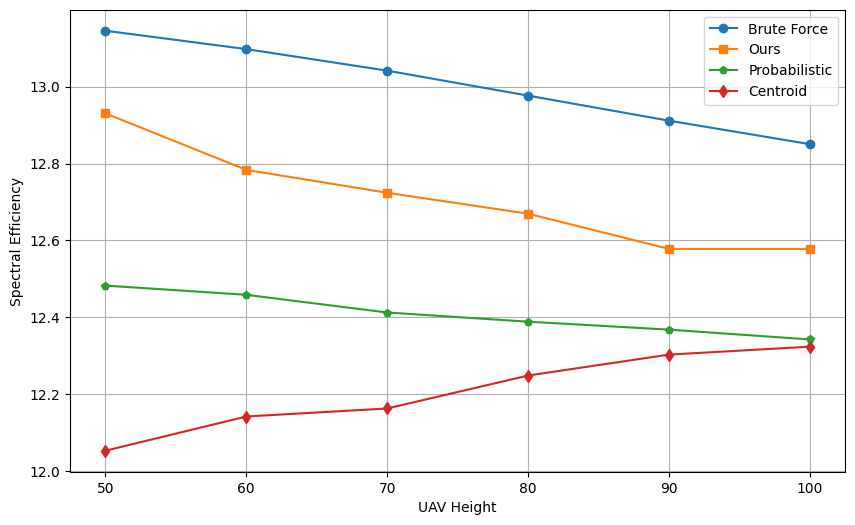

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# x축 값을 2부터 8까지 생성 (길이 7)
x = np.arange(50, 110, 10)

brute_force = np.array([np.mean(data['bf_se']) for data in se_result])
ours = np.array([np.mean(data['dl_se']) for data in se_result])
cent = np.array([np.mean(data['cent_se']) for data in se_result])
prob = np.array([np.mean(data['prob_se']) for data in se_result])

plt.plot(x, brute_force, marker='o', label='Brute Force')
plt.plot(x, ours, marker='s', label='Ours')
plt.plot(x, prob, marker='p', label='Probabilistic')
plt.plot(x, cent, marker='d', label='Centroid')

plt.xlabel('UAV Height')
plt.ylabel('Spectral Efficiency')
plt.legend()
plt.grid()
plt.show()

In [4]:
print(f"Brute Force:   {brute_force}")
print(f"Ours:          {ours}")
print(f"Probabilistic: {prob}")
print(f"Centroid:      {cent}")
print(f"Gap:           {brute_force - ours}")

Brute Force:   [13.145334 13.097577 13.041532 12.976624 12.91145  12.850361]
Ours:          [12.930493 12.783555 12.724037 12.669608 12.578106 12.578095]
Probabilistic: [12.482716 12.458763 12.412761 12.388867 12.368231 12.342677]
Centroid:      [12.053415 12.142378 12.163232 12.248897 12.303302 12.323906]
Gap:           [0.21484089 0.31402206 0.3174944  0.30701542 0.33334446 0.27226543]
